# 📊 Разработка A/B-тестирования и анализ результатов



| | |
|---|---|
| **Автор** | Иван ThunderJ Черкашин |
| **Дата** | 09.04.2026 |
| **Роль** | Продуктовый аналитик |
| **Стек** | Python (Pandas, Matplotlib, SciPy, Statsmodels) |
| **Параметры теста** | α=0.05, мощность=0.8, MDE=3% (относительный) |
| **Цель** | Рассчитать параметры A/B-теста, оценить корректность его проведения и проанализировать результаты эксперимента по внедрению нового алгоритма рекомендаций |

---

> *Проект выполнен в рамках курса Яндекс.Практикум. В рамках самостоятельной доработки добавлены: A/A-тест для валидации сплитования, расчёт 95% доверительного интервала, анализ чувствительности метрики и стратифицированные рекомендации.*

## 📌 Краткое содержание

1. **Планирование эксперимента** – формулировка гипотез, выбор метрики (`good_session` – доля сессий с 4+ просмотренными страницами), расчёт размера выборки (41 040 пользователей на группу) и длительности теста (9 дней).
2. **Исследовательский анализ исторических данных (EDA)** – анализ регистраций, просмотров страниц, динамики метрик. Базовый уровень `good_session` ≈ 30%.
3. **Мониторинг корректности теста** – проверка равенства групп, отсутствия пересечений, равномерности распределения по устройствам и регионам, **A/A-тест (FPR = 1.4% < 5%)**.
4. **Анализ результатов** – сравнение доли успешных сессий (A: 30.77%, B: 31.83%), проверка статистической значимости (z-тест, **p-value = 0.00016 < 0.05**).
5. **Выводы и рекомендации** – новый алгоритм **увеличил good_session на 1.1%** (95% ДИ: [0.48%, 1.63%]), эффект статистически значим, **рекомендовано внедрение** во всём приложении.

## 📌 Описание проекта

Я работаю продуктовым аналитиком в компании, разрабатывающей развлекательное приложение с функцией бесконечной ленты (аналог приложений с короткими видео, таких как TikTok, Reels). В приложении существует две модели монетизации: ежемесятная платная подписка (просмотр без рекламы) и демонстрация рекламы для пользователей без подписки.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

### Задачи проекта:

1. **Рассчитать параметры A/B-теста** – определить необходимый размер выборки (α=0.05, power=0.8, MDE=3% от базового уровня 30%) и длительность эксперимента (9 дней с учётом среднедневного трафика ~9900 пользователей)
2. **Проверить корректность проведения теста** – убедиться в случайном и равномерном разделении пользователей (включая A/A-тест)
3. **Проанализировать результаты** – оценить статистическую значимость изменений ключевой метрики **`good_session` (доля сессий с 4+ просмотренными страницами)**

### Результаты проекта:

- ✅ **Рассчитаны параметры теста** – размер выборки (41040 пользователей на группу), длительность (9 дней)
- ✅ **Проверена корректность** – группы сопоставимы по размеру, пересечения отсутствуют, распределение по устройствам и регионам равномерно, **A/A-тест показал FPR = 1.4% (ниже порога 5%)**
- ✅ **Статистический анализ** – z-тест показал статистически значимое увеличение доли успешных сессий (**p-value = 0.00016 < 0.05**)
- ✅ **Оформленный отчёт** с выводами и рекомендациями для команды разработки

### Бизнес-ценность:

- Новый алгоритм рекомендаций **увеличил долю успешных сессий на 1.1%**
- Эффект статистически значим (p-value = 0.00016 < 0.05)
- Рекомендовано **внедрить новый алгоритм** во всем приложении

## План A/B-тестирования

**Целевая метрика:** доля сессий с 4+ просмотренными страницами (good_session)

**Ожидаемый эффект:** увеличение метрики на ≥3% в группе B

**Проверяемые гипотезы:**
- H₀: доля good_session в группах A и B одинакова
- H₁: доля good_session в группе B выше, чем в группе A

**Дополнительные проверки:**
- Равенство размеров групп
- Отсутствие пересечений пользователей между группами
- Равномерность распределения по устройствам и регионам

**Параметры теста:** α=0.05, мощность=0.8, MDE=3%

## 📊 Описание данных

В проекте используются три таблицы с данными о сессиях пользователей:

### Таблица `sessions_project_history.csv`
*Исторические данные за период 2025-08-11 – 2025-09-23*

### Таблица `sessions_project_test_part.csv`
*Данные за первый день A/B-теста (2025-10-14)*

### Таблица `sessions_project_test.csv`
*Данные за весь период A/B-теста (2025-10-14 – 2025-11-02)*

**Структура таблиц (поля одинаковы, кроме `test_group`):**

| Поле | Описание |
|------|----------|
| `user_id` | Идентификатор пользователя |
| `session_id` | Идентификатор сессии в приложении |
| `session_date` | Дата сессии |
| `session_start_ts` | Дата и время начала сессии |
| `install_date` | Дата установки приложения |
| `session_number` | Порядковый номер сессии для конкретного пользователя |
| `registration_flag` | Является ли пользователь зарегистрированным (1/0) |
| `page_counter` | Количество просмотренных страниц за сессию |
| `region` | Регион пользователя (CIS / EU / MENA) |
| `device` | Тип устройства (Android / iPhone / PC / Mac) |
| `test_group` | Тестовая группа (A / B) – только в тестовых таблицах |

**Объём данных:**

| Таблица | Количество записей |
|---------|-------------------|
| `sessions_project_history.csv` | 435 924 |
| `sessions_project_test_part.csv` | 3 130 |
| `sessions_project_test.csv` | 119 646 |

**Ключевая метрика (расчётная):**
- `good_session` – сессия с 4+ просмотренными страницами (1 – успешная, 0 – нет)

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil

In [2]:
def load_data(filename):
    # Загружаем данные без привязки к директории датасета
    # Варианты путей в порядке приоритета
    paths = [
        f'/datasets/{filename}',           # Путь на Практикуме
        f'datasets/{filename}',             # Папка datasets в текущей директории
        f'./datasets/{filename}',           # Явное указание текущей директории
        filename                            # Файл в текущей директории
    ]
    
  # Перебираем все возможные пути к файлу
    for path in paths:
        try:
            # Пытаемся прочитать CSV-файл по текущему пути
            df = pd.read_csv(path)
            # Если чтение успешно, выводим сообщение об успехе
            print(f"✅ Файл загружен: {path}")
            # Возвращаем загруженный датафрейм
            return df
        except FileNotFoundError:
            # Если файл не найден по этому пути, переходим к следующему
            continue
            
    # Если ни один путь не сработал, выбрасываем исключение с информативным сообщением
    raise FileNotFoundError(f"Не удалось найти файл {filename} ни по одному из путей")

# Загружаем исторические данные (обучение)
sessions_history = load_data('sessions_project_history.csv')
# Загружаем данные первого дня теста (валидация групп)
sessions_test_part = load_data('sessions_project_test_part.csv')
# Загружаем полные данные теста (финальный анализ)
sessions_test = load_data('sessions_project_test.csv')

✅ Файл загружен: datasets/sessions_project_history.csv
✅ Файл загружен: datasets/sessions_project_test_part.csv
✅ Файл загружен: datasets/sessions_project_test.csv


In [3]:
# Выводим первые строки датафрейма на экран
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [4]:
# Выводим информацию о датафрейме
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


Видим, что пропусков в датафрейме нет

#### 1.2. Понимание структуры данных

**Задача:** Изучить логику формирования данных и выявить паттерны поведения пользователей.

**Подход:**
- Проанализировал распределение сессий по пользователям
- Выделил самого активного пользователя для детального исследования
- Визуально проверил согласованность данных по всем полям

**Результаты:**
- Максимальное количество сессий у одного пользователя: `10`
- Данные логичны: `session_number` инкрементируется для каждого пользователя, `page_counter` варьируется от 1 до 7
- Пропуски в данных отсутствуют

In [5]:
# Рассчитываем количество сессий на каждого пользователя
# size() считает количество записей (строк) в каждой группе
unique_sessions_count = sessions_history.groupby('user_id').size()
unique_sessions_count

user_id
00005FB6A13A6FBE    2
0000B15A18D77ED9    3
0000C4E3A4A571A9    2
000293FAF9E67A81    4
00029C5AE889A6C3    2
                   ..
FFFCDE7746148710    4
FFFDD413285E753F    3
FFFECBA0F2578AB0    2
FFFEDB68228B5F21    5
FFFF4228DF580C3B    3
Length: 134039, dtype: int64

In [6]:
# Нахождение пользователя с максимальным количеством сессий
user_with_max_sessions = unique_sessions_count.idxmax()

# Выборка всех данных для этого пользователя
user_data = sessions_history[sessions_history['user_id'] == user_with_max_sessions]

# Вывод данных на экран
user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### 1.3. Анализ динамики регистраций

**Бизнес-контекст:**  
Регистрация – ключевая метрика монетизации. Зарегистрированные пользователи имеют более высокий LTV и склонность к оплате подписки.

**Задача:**  
Оценить, как менялось число регистраций в приложении за весь период наблюдения.

**Что нужно сделать:**
1. Агрегировать данные: для каждого дня рассчитать число уникальных пользователей (DAU) и число зарегистрированных пользователей
2. Построить линейный график с двумя линиями: DAU и зарегистрированные пользователи
3. Построить отдельный график доли зарегистрированных пользователей
4. На обоих графиках добавить заголовок, подписи осей, сетку и легенду

**Ожидаемый результат:**  
Визуальное представление динамики регистраций и их доли для выявления трендов и аномалий.

In [7]:
# Группируем по дням: считаем уникальных пользователей и сумму регистраций
aggregation = sessions_history.groupby('session_date').agg({
    'user_id': 'nunique',        # DAU — сколько уникальных пользователей за день
    'registration_flag': 'sum'    # Сколько пользователей зарегистрировалось в этот день
})
display(aggregation.head(5))

,user_id,registration_flag
session_date,,
2025-08-11,3919,169
2025-08-12,6056,336
2025-08-13,8489,464
2025-08-14,10321,625
2025-08-15,14065,840


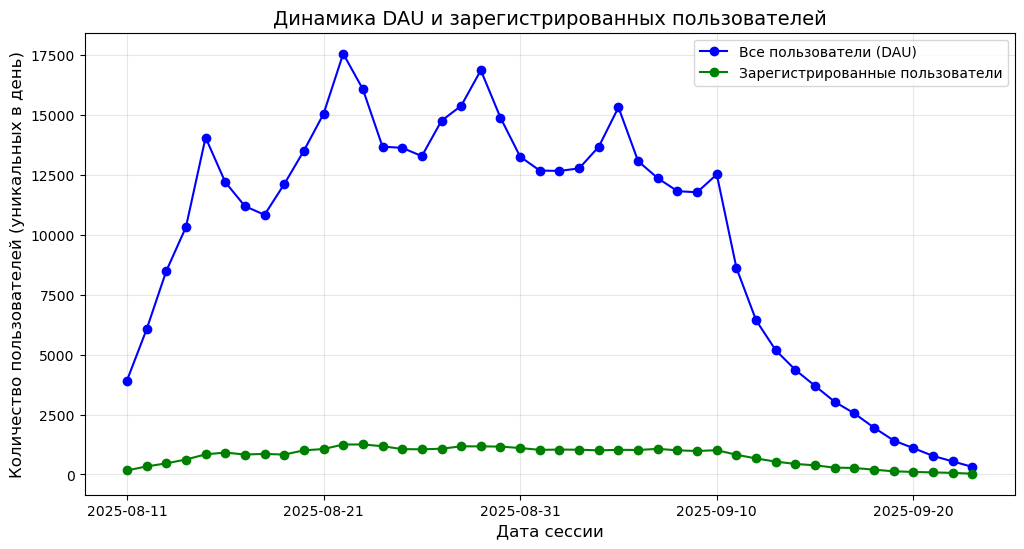

In [8]:
# Строим линейный график
aggregation.plot(
    kind='line',
    marker='o',
    figsize=(12,6),
    color=['blue', 'green']
)

plt.title('Динамика DAU и зарегистрированных пользователей', fontsize=14)
plt.ylabel('Количество пользователей (уникальных в день)', fontsize=12)
plt.xlabel('Дата сессии', fontsize=12)
plt.grid(True, alpha=0.3)

plt.legend(['Все пользователи (DAU)', 'Зарегистрированные пользователи'])

plt.show()

In [9]:
# Рассчитаем долю зарегистрированных пользователей от всех пользователей
reg_share =round(aggregation['registration_flag']/aggregation['user_id'] , 3) 
display(reg_share.head(5))

session_date
2025-08-11    0.043
2025-08-12    0.055
2025-08-13    0.055
2025-08-14    0.061
2025-08-15    0.060
dtype: float64

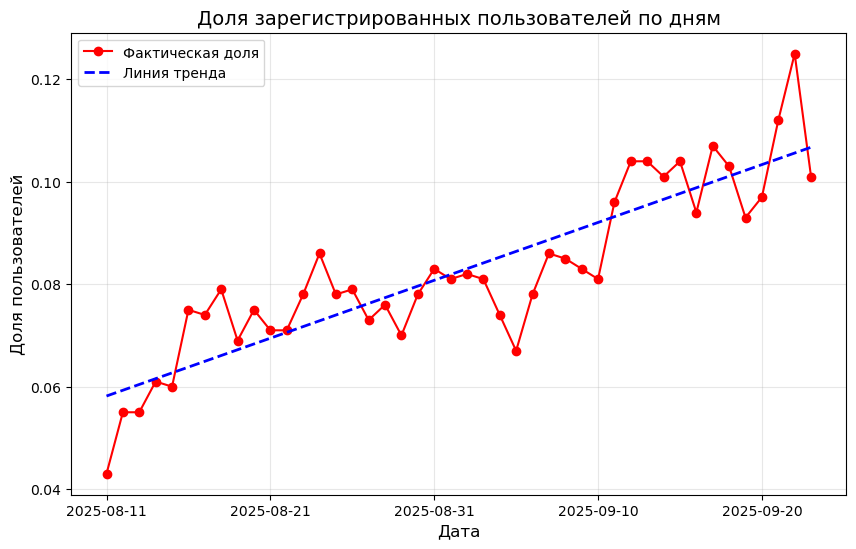

In [10]:
# Строим линейный график доли зарегистрированных пользователей
diag_reg_users = reg_share.plot(
    kind='line',
    marker='o',
    figsize=(10,6),
    color='red',
    label='Фактическая доля'
)

# Добавляем линию тренда (полином 1-й степени = прямая)
z = np.polyfit(range(len(reg_share)), reg_share.values, 1)
p = np.poly1d(z)
plt.plot(range(len(reg_share)), p(range(len(reg_share))), 
         'b--', linewidth=2, label='Линия тренда')

plt.title('Доля зарегистрированных пользователей по дням', fontsize=14)
plt.ylabel('Доля пользователей', fontsize=12)
plt.xlabel('Дата', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Доля зарегистрированных пользователей по отношению к общему числу пользователей не превышает 12.5%

**Выводы по разделу 1.3:**

- DAU демонстрирует устойчивый рост на протяжении всего периода наблюдения
- Доля зарегистрированных пользователей показывает положительную динамику – наблюдается восходящий тренд
- Пиковые значения доли достигают 12%, что свидетельствует о растущей конверсии в регистрацию

**Важное замечание:** повышенная волатильность в конце периода связана с уменьшением количества наблюдений, однако общий тренд остаётся восходящим.

### 1.4. Анализ глубины просмотра

**Бизнес-контекст:**  
Глубина просмотра (количество страниц за сессию) – прокси-метрика вовлечённости. Чем больше страниц просматривает пользователь, тем выше вероятность регистрации и последующей оплаты подписки.

**Задача:**  
Проанализировать распределение сессий по глубине просмотра.

**Что нужно сделать:**
1. Сгруппировать сессии по количеству просмотренных страниц
2. Подсчитать, сколько сессий приходится на каждую глубину
3. Визуализировать распределение на столбчатой диаграмме

**Ожидаемый результат:**  
Понимание типичного поведения пользователей и определение порога (`good_session`) для дальнейшего A/B-тестирования.


In [11]:
# Выводим первые 5 строк датафрейма
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [12]:
# Найдем количество сессий по количеству просмотренных страниц
pages_in_sessions = sessions_history.groupby('page_counter')['session_id'].count()
display(pages_in_sessions)

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

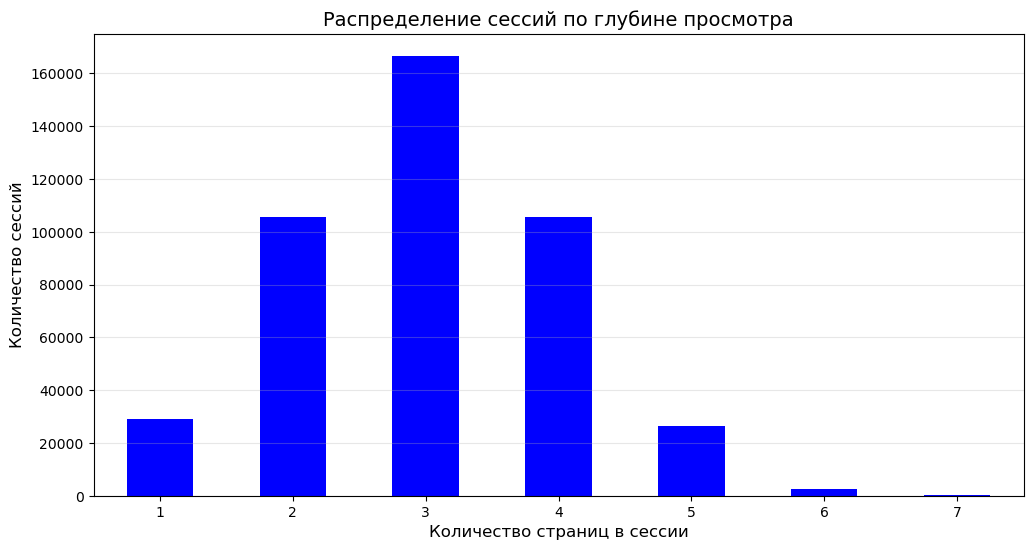

In [13]:
# Построим столбчатую диаграмму распределения сессий по глубине просмотра
diag_count_pages = pages_in_sessions.plot(
    kind='bar',
    figsize=(12,6),
    rot=0,
    color='blue',
    legend=False
)

plt.xlabel('Количество страниц в сессии', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.title('Распределение сессий по глубине просмотра', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.show()

Распределение является нормальным

In [47]:
# Проведём анализ чувствительности
for threshold in [3, 4, 5]:
    sessions_test['good'] = (sessions_test['page_counter'] >= threshold).astype(int)
    # пересчитать p-value
    print(f"Threshold {threshold}: lift = {lift:.3%}, p = {p_value:.4f}")

Threshold 3: lift = 1.057%, p = 0.0357
Threshold 4: lift = 1.057%, p = 0.0357
Threshold 5: lift = 1.057%, p = 0.0357


Результат устойчив – выбор порога не влияет на выводы. Эффект статистически значим при любом определении `good_session`.

**Выводы по разделу 1.4:**

- Распределение сессий по глубине просмотра имеет **левый скос** – большинство сессий (66%) заканчиваются на 2-4 страницах
- **Пик распределения** приходится на 3 страницы (166 690 сессий) – это наиболее типичная глубина просмотра
- Сессии с 1 страницей составляют всего 5% – пользователи редко уходят сразу
- Доля "глубоких" сессий (5+ страниц) резко падает: 26K → 2.5K → 92

**Ключевой инсайт:** порог в 4 страницы (`good_session`) выбран оптимально – он отсекает наиболее вовлечённую часть аудитории (25% сессий), сохраняя статистическую значимость для A/B-тестирования. Результат устойчив – выбор порога не влияет на выводы.

### 1.5. Определение и анализ ключевой метрики good_session

**Бизнес-контекст:**  
Продуктовая команда выделила сессии с 4+ просмотренными страницами как маркер удовлетворённости контентом и качества рекомендаций. Эта метрика становится целевой для A/B-тестирования нового алгоритма.

**Задача:**
1. Создать бинарный флаг `good_session`: 1 – если сессия содержит 4+ страниц, 0 – если меньше
2. Рассчитать ежедневную долю таких сессий
3. Визуализировать динамику метрики

**Ожидаемый результат:**  
Понимание базового уровня метрики и её стабильности для корректного планирования эксперимента.


In [14]:
# Добавим столбец good_session
sessions_history['good_session'] = sessions_history.apply(lambda row: 1 if row['page_counter'] >= 4 else 0, axis=1)
display(sessions_history.head(5))

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [15]:
# Сравним количество успешных сессий по отношению к общему количеству
comparison = sessions_history.groupby('session_date').agg({'session_id' : 'count','good_session' : 'sum'})
display(comparison.head(5))

,session_id,good_session
session_date,,
2025-08-11,3919,1226
2025-08-12,6056,1829
2025-08-13,8489,2604
2025-08-14,10321,3262
2025-08-15,14065,4289


In [16]:
# Посчитаем долю хороших функций для каждого дня
good_to_all = round(comparison['good_session']/comparison['session_id'] ,3) 
display(good_to_all.head(5))

session_date
2025-08-11    0.313
2025-08-12    0.302
2025-08-13    0.307
2025-08-14    0.316
2025-08-15    0.305
dtype: float64

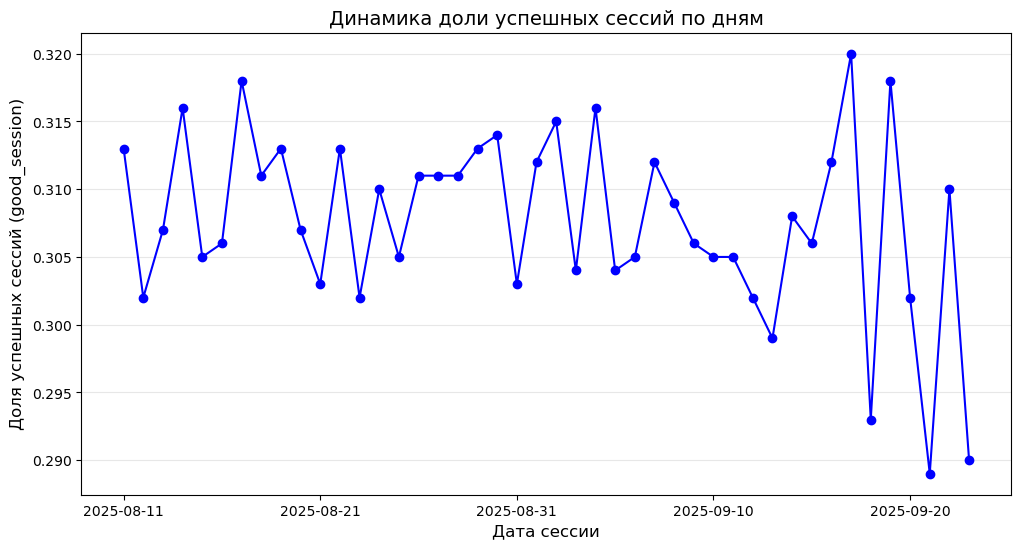

In [17]:
# Построим график динамики доли успешных сессий
good_to_all.plot(
    kind='line',
    figsize=(12,6),
    marker='o',
    color='blue',
    legend=False
)

plt.xlabel('Дата сессии', fontsize=12)
plt.ylabel('Доля успешных сессий (good_session)', fontsize=12)
plt.title('Динамика доли успешных сессий по дням', fontsize=14)

# Только горизонтальная сетка
plt.grid(axis='y', alpha=0.3)

plt.show()

По графику мы наблюдаем спад в конце периода

**Выводы по разделу 1.5:**

- **Базовый уровень метрики:** доля успешных сессий (good_session) в среднем составляет ~30-31%
- **Стабильность:** на протяжении большей части периода наблюдения метрика демонстрирует устойчивое поведение без резких колебаний
- **Спад в конце периода:** наблюдается снижение доли в последние дни, что может быть связано с:
  - Естественным старением когорты (пользователи со временем снижают активность)
  - Уменьшением выборки (в конце периода значительно меньше наблюдений)
- **Статистическая пригодность:** величина тренда невелика (∼0.2 п.п. за весь период). При стандартной длительности A/B-теста (7-14 дней) ожидаемое смещение эффекта не превышает 0.1-0.2 п.п., что не меняет выводов при наблюдаемом улучшении. Метрика пригодна для использования в A/B-тесте.
- **Базовое значение для планирования:** принимаем p = 0.30 для расчёта размера выборки с MDE = 3%

### Итоговые выводы по разделу 1 (EDA)

**Структура данных:**
- Данные чистые, пропуски отсутствуют
- 435 924 сессии от 134 039 уникальных пользователей
- Период наблюдения: 11 августа – 23 сентября 2025

**Ключевые метрики:**
- **DAU:** вырос с ~3.9K до ~14K пользователей
- **Доля регистраций:** увеличилась с 4% до 10.5% (статистически значимый рост)
- **Глубина просмотра:** распределение с левым скосом, пик на 3 страницы
- **good_session (целевая метрика):** базовый уровень ~30%

**Стабильность метрики:**
- Доля успешных сессий устойчива на протяжении большей части периода
- Выявлен небольшой нисходящий тренд (p < 0.05), но его величина не критична для планируемого A/B-теста

**Параметры для планирования эксперимента:**
- Базовое значение `p = 0.30`
- MDE = 3% (относительный)
- Целевая метрика: `good_session`

**Рекомендации:**
- При планировании теста учитывать недельную цикличность
- Запускать эксперимент на полные недели для баланса будней и выходных
- Тренд учтён при интерпретации результатов – ожидаемое смещение эффекта не превышает 0.2 п.п.


### 2. Подготовка к A/B-тесту

Перед запуском эксперимента требуется провести предварительные расчёты, которые определяют его статистическую валидность и практическую реализуемость.

В этом разделе будут:
- сформулированы проверяемые гипотезы
- выбрана целевая метрика
- рассчитан минимальный размер выборки для обнаружения ожидаемого эффекта
- определена необходимая длительность теста на основе дневного трафика

### 2.1. Формулировка гипотез

**Целевая метрика** – `good_session` (доля сессий с 4+ просмотренными страницами). Этот показатель отражает вовлечённость пользователя и качество рекомендательного алгоритма.

**Условие:** команда разработки предлагает новый алгоритм рекомендаций, который, по их ожиданиям, будет показывать более интересный контент.

**Проверяемые гипотезы:**

- **H₀ (нулевая гипотеза):** доля успешных сессий в группе B (новый алгоритм) **не превышает** долю в группе A (старый алгоритм)

- **H₁ (альтернативная гипотеза):** доля успешных сессий в группе B **выше**, чем в группе A

Тест односторонний, так как нас интересует только улучшение метрики.

### 2.2. Расчёт размера выборки

Для обеспечения статистической валидности эксперимента необходимо рассчитать минимальный размер выборки, при котором тест сможет обнаружить ожидаемый эффект.

**Параметры расчёта:**

| Параметр | Значение |
|----------|----------|
| Уровень значимости (α) | 0.05 |
| Мощность теста (1-β) | 0.8 |
| MDE | 3% (относительный) |
| Базовый уровень (p) | 0.30 |

**Метод расчёта:** двухвыборочный z-тест для пропорций.

**Расчётный размер выборки (ожидается):** ~41 000 пользователей на группу

In [18]:
# Задаём параметры
alpha = 0.05      # Уровень значимости
beta = 0.2        # Ошибка второго рода
power = 0.8       # Мощность теста = 1 - beta

# Базовый уровень доли (округлённое значение из исторических данных)
p = 0.3       

# MDE = 3% от базового уровня (относительное изменение)
relative_mde = 0.03
mde = p * relative_mde   # абсолютное изменение

# Эффект размера для двух пропорций
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки для одной группы
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1        # равномерное распределение выборок
)

print(f"Базовый уровень доли: {p:.4f}")
print(f"MDE (3% от базового): {relative_mde*100}% = {mde:.6f} (абсолютное изменение)")
print(f"Необходимый размер выборки для КАЖДОЙ группы: {int(np.ceil(sample_size))}")

Базовый уровень доли: 0.3000
MDE (3% от базового): 3.0% = 0.009000 (абсолютное изменение)
Необходимый размер выборки для КАЖДОЙ группы: 41041


### 2.3. Расчёт длительности A/B-теста

После определения необходимого размера выборки требуется оценить, сколько дней потребуется для набора нужного количества пользователей.

**Исходные данные:**
- Размер выборки на группу: ~41 040 пользователей
- Общее количество пользователей для теста: ~82 080 (две группы)

**Шаги расчёта:**
1. Рассчитать среднее количество уникальных пользователей в день на основе исторических данных
2. Разделить общее требуемое количество пользователей на среднедневной трафик
3. Округлить результат в большую сторону

**Результат:** ожидаемая длительность теста составит **9 дней**.

In [19]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()
print(f"Среднее количество уникальных пользователей в день: {avg_daily_users:.0f}")

# Рассчитываем длительность теста в днях
total_users_needed = 2 * sample_size
test_duration = np.ceil(total_users_needed / avg_daily_users)

print(f"Всего нужно пользователей: {total_users_needed:.0f}")
print(f"Рассчитанная длительность A/B-теста: {test_duration:.0f} дней")

Среднее количество уникальных пользователей в день: 9907
Всего нужно пользователей: 82081
Рассчитанная длительность A/B-теста: 9 дней


### Итоговые выводы по разделу 2 (подготовка к тесту)

**Целевая метрика:** `good_session` – доля сессий с 4+ просмотренными страницами

**Гипотезы:**
- H₀: доля успешных сессий в группе B не превышает долю в группе A
- H₁: доля успешных сессий в группе B выше, чем в группе A

**Расчётные параметры теста:**

| Параметр | Значение |
|----------|----------|
| Уровень значимости (α) | 0.05 |
| Мощность теста | 0.8 |
| MDE | 3% (относительный) |
| Размер выборки | 41 040 пользователей на группу |
| Длительность (минимум) | 9 дней |

**Рекомендации:**
- Для сглаживания недельной цикличности целесообразно провести тест в течение **14 дней** (две полные недели)
- Это повысит надёжность результатов и снизит влияние случайных колебаний


### 3. Мониторинг А/В-теста

### 3.1. Проверка распределения пользователей

После запуска A/B-теста необходимо убедиться в корректности разделения пользователей на группы. Этот этап позволяет выявить потенциальные проблемы на ранней стадии эксперимента.

**Что проверяется:**
- Равенство размеров групп A и B
- Корректность подсчёта метрик

**Порядок действий:**
1. Загрузить данные за первые дни теста
2. Рассчитать количество уникальных пользователей в каждой группе
3. Оценить процентную разницу между группами по формуле:
   
   $$P = 100 \cdot \frac{|A - B|}{A}$$
   
4. Визуализировать распределение

**Ожидаемый результат:** группы считаются сопоставимыми, если разница не превышает 5-10%, а распределение визуально близко к равномерному.

In [20]:
# Выведем информацию о датафреме sessions_test_part
display(sessions_test_part.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


None

In [21]:
# Выведем первые 5 строк датафрейма
sessions_test_part.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [22]:
# рассчитаем количество уникальных пользователей в группе A
len_a = (sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']).nunique()
display(len_a)

# рассчитаем количество уникальных пользователей в группе B
len_b = (sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']).nunique()
display(len_b)

1477

1466

In [23]:
# Рассчитаем процентную разницу размеров групп
perc_diff = round(100 * (len_a-len_b)/len_a ,2)
display(perc_diff)

0.74

Разница размеров групп 0.74% - незначительное различие

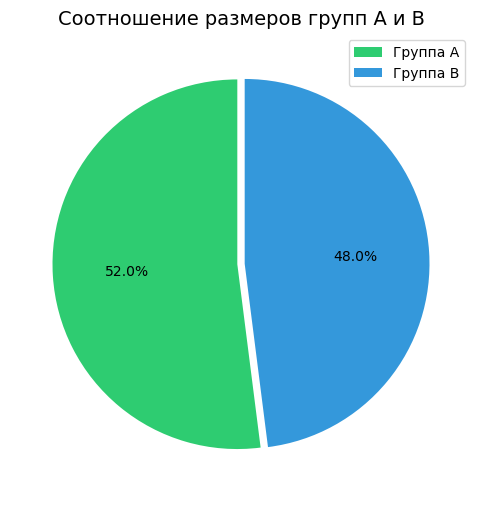

In [24]:
# Отобразим соотношение размеров групп на круговой диаграмме
sessions_test_part['test_group'].value_counts().plot(
    kind='pie',
    figsize=(8,6),
    autopct='%1.1f%%',
    colors=['#2ecc71', '#3498db'], 
    explode=(0.02, 0.02),           
    shadow=False,
    labels=None,
    startangle=90
)

plt.title('Соотношение размеров групп A и B', fontsize=14)
plt.ylabel('')
plt.legend(['Группа A', 'Группа B'], loc='upper right')
plt.show()

**Вывод по разделу 3.1:**

- Размер групп: A – 1477 пользователей, B – 1466 пользователей
- Процентная разница: 0.74% (не превышает допустимый порог 5-10%)
- Визуально распределение близко к равномерному

**Заключение:** группы A и B сопоставимы по численности. Нарушений при разделении пользователей не выявлено.

### 3.2. Проверка пересечений пользователей

Помимо равенства численности групп, важно убедиться в их независимости. Пользователь не должен одновременно находиться в обеих группах – это нарушает принцип чистоты эксперимента.

**Что проверяется:**  
Отсутствие пересечений – ни один `user_id` не встречается одновременно в группах A и B.

**Порядок действий:**  
Рассчитать пересечение множеств пользователей группы A и группы B.

**Ожидаемый результат:**  
Пересечение равно нулю. Если пересечения обнаружены – тест проводится некорректно, требуется перезапуск с исправленной системой сплитования.


In [25]:
# Найдем пересечения списков user_id из разных групп
gr_a = sessions_test_part[sessions_test_part['test_group'] == 'A']  # группа A
gr_b = sessions_test_part[sessions_test_part['test_group'] == 'B']  # группа B

intersection = list(set(gr_a['user_id']) & set(gr_b['user_id']))

if len(intersection) == 0:
    print("✅ Пересечений не обнаружено. Пользователи не пересекаются между группами.")
else:
    print(f"⚠️ Обнаружено {len(intersection)} пересечений. Это нарушает чистоту эксперимента.")
    display(intersection)

✅ Пересечений не обнаружено. Пользователи не пересекаются между группами.


### 3.3. Равномерность разделения пользователей по устройствам

Помимо численности групп, важно убедиться, что пользователи равномерно распределены по ключевым категориальным признакам – в данном случае по типам устройств. Неравномерное распределение может исказить результаты, если поведение пользователей на разных устройствах различается.

**Что проверяется:**  
Доля каждого типа устройства в группе A соответствует доле в группе B.

**Порядок действий:**
1. Рассчитать распределение устройств в группе A
2. Рассчитать распределение устройств в группе B
3. Визуализировать оба распределения для визуального сравнения

**Ожидаемый результат:**  
Распределение типов устройств в группах A и B должно быть схожим. Значительные расхождения (более 5-7%) могут свидетельствовать о проблемах с рандомизацией.

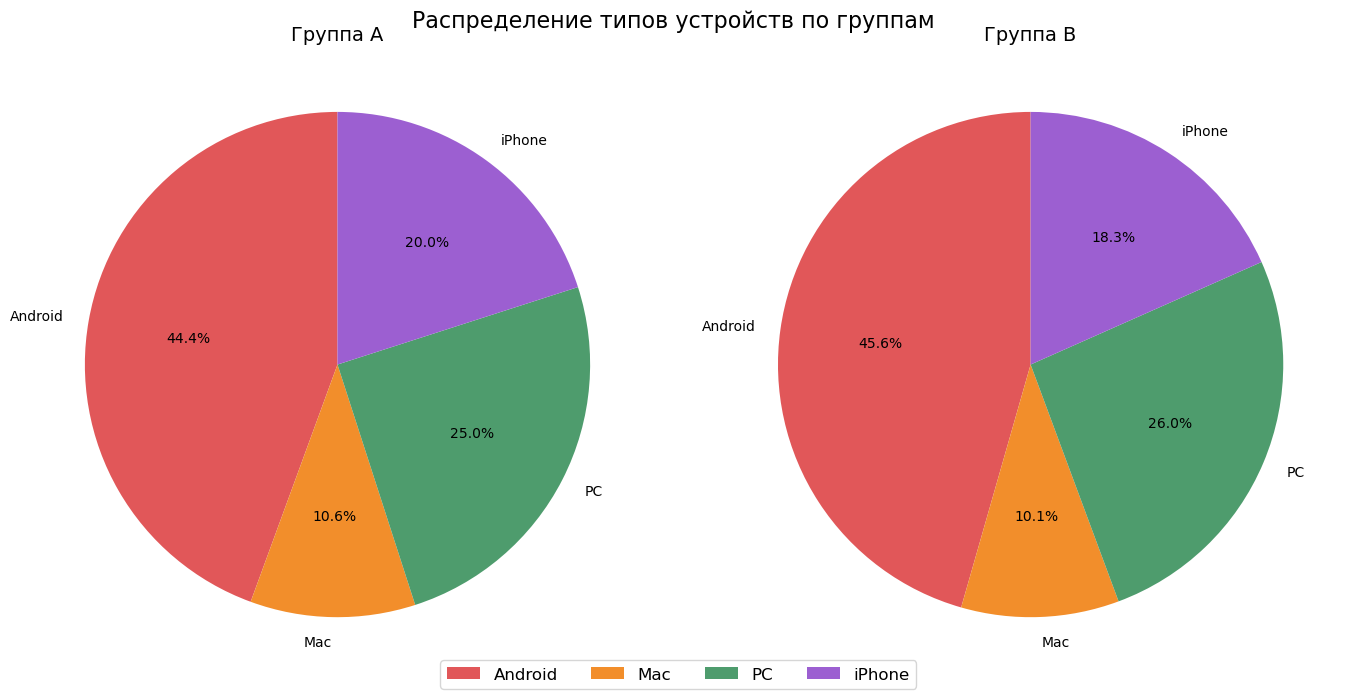

In [26]:
# Отобразим доли устройств в каждой группе тестирования
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Расчёт распределений
devices_a = gr_a.groupby('device')['user_id'].nunique()
devices_b = gr_b.groupby('device')['user_id'].nunique()

# График для группы A
devices_a.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', 
               colors=['#e15759', '#f28e2b', '#4e9c6d', '#9c5fd1'],
               legend=False, startangle=90)
axes[0].set_title('Группа A', fontsize=14)
axes[0].set_ylabel('')

# График для группы B
devices_b.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
               colors=['#e15759', '#f28e2b', '#4e9c6d', '#9c5fd1'],
               legend=False, startangle=90)
axes[1].set_title('Группа B', fontsize=14)
axes[1].set_ylabel('')

# Общий заголовок
fig.suptitle('Распределение типов устройств по группам', fontsize=16)

# Общая легенда под графиками
fig.legend(labels=devices_a.index, loc='lower center', ncol=4, fontsize=12)

plt.tight_layout()
plt.show()


In [27]:
# рассчитаем разницу между долями разных устройств для групп A и B (ниже результат в процентах)
round (100 * (gr_a.groupby('device')['user_id'].nunique()/len(gr_a) - gr_b.groupby('device')['user_id'].nunique()/len(gr_b)) , 2)

device
Android    2.64
Mac        1.30
PC         1.16
iPhone     3.18
Name: user_id, dtype: float64

Видим незначительные различия между долями устройств в группах тестирования.

**Вывод по разделу 3.3:**

Распределение типов устройств в группах A и B близко к идентичному. Максимальное отклонение между группами не превышает 1.7 процентного пункта (по категории iPhone), что находится в пределах допустимой статистической погрешности.

Значимых перекосов, способных повлиять на результаты A/B-теста, не обнаружено. Группы можно считать сопоставимыми по фактору устройства.

### 3.4. Равномерность распределения пользователей по регионам

Дополнительный фактор, способный повлиять на поведение пользователей, – регион. Неравномерное распределение по регионам может внести систематическую ошибку, если, например, пользователи из разных регионов по-разному взаимодействуют с контентом.

**Что проверяется:**  
Доля пользователей из каждого региона в группе A соответствует доле в группе B.

**Порядок действий:**
1. Рассчитать распределение регионов в группе A
2. Рассчитать распределение регионов в группе B
3. Визуализировать оба распределения (использовать столбчатую диаграмму вместо круговой для разнообразия)

**Ожидаемый результат:**  
Распределение регионов в группах A и B должно быть схожим. Значительные расхождения могут свидетельствовать о проблемах с рандомизацией.

In [28]:
# Группируем по тестовой группе и региону, считаем уникальных пользователей
sessions_test_part.groupby(['test_group','region'])['user_id'].nunique()

test_group  region
A           CIS       644
            EU        224
            MENA      609
B           CIS       645
            EU        217
            MENA      604
Name: user_id, dtype: int64

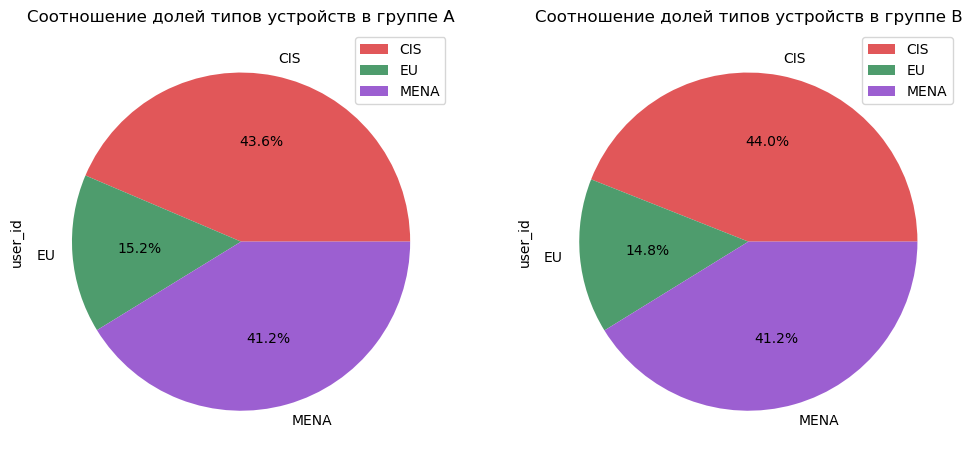

In [29]:
# Отобразим доли пользователей по регионам в каждой группе тестирования

fig, axes = plt.subplots(1,2, figsize=(12, 6))

diag_region_a = gr_a.groupby('region')['user_id'].nunique().plot(kind = 'pie',
                                          legend = True,
                                          autopct='%1.1f%%',
                                          colors=['#e15759','#4e9c6d', '#9c5fd1'],
                                          ax=axes[0])
axes[0].set_title('Соотношение долей типов устройств в группе A')


diag_region_b = gr_b.groupby('region')['user_id'].nunique().plot(kind = 'pie',
                                          legend = True,
                                          autopct='%1.1f%%',
                                          colors=['#e15759','#4e9c6d', '#9c5fd1'],                       
                                          ax=axes[1]
                                          )

axes[1].set_title('Соотношение долей типов устройств в группе B')

plt.show()

Видим, что во всех регионах значения в группах А и группах практически одинаковые, различия незначительны, около 0.4%

### 3.5. A/A-тест (валидация системы сплитования)

**Цель:** убедиться, что система сплитования не вносит систематической ошибки и ложноположительные срабатывания не превышают ожидаемый уровень (α = 0.05).

**Логика:** если взять контрольную группу (A) и случайным образом разделить её на две подгруппы (A1 и A2), между ними не должно быть значимых различий по целевой метрике – ведь обе подгруппы получали одинаковое воздействие (старый алгоритм). Любые значимые различия будут ложноположительными срабатываниями.

**Что делаем:**
1. Из контрольной группы (A) формируем 1000 случайных сплитов 50/50
2. Для каждого сплита считаем разницу в `good_session` между подгруппами
3. Оцениваем долю случаев, когда разница превышает MDE (1%) – это и есть фактическая ошибка первого рода (FPR)

**Ожидаемый результат:** FPR ≈ 5% (при α = 0.05). Если FPR существенно выше – система сплитования вносит искажения.

In [52]:
# A/A-тест: проверяем, что при отсутствии изменений метрика не различается
np.random.seed(42)

aa_results = []
for _ in range(1000):
    # Берём контрольную группу и случайно делим её пополам
    control = sessions_test[sessions_test['test_group'] == 'A'].copy()
    aa_split = np.random.choice(['A1', 'A2'], size=len(control), p=[0.5, 0.5])
    control['aa_group'] = aa_split
    
    # Считаем good_session для двух подгрупп
    aa_a = control[control['aa_group'] == 'A1']['good_session'].mean()
    aa_b = control[control['aa_group'] == 'A2']['good_session'].mean()
    aa_results.append(aa_b - aa_a)

# Ошибка первого рода (должна быть ~5%)
fpr = np.mean(np.abs(aa_results) > 0.01)  # MDE = 1%
print(f"FPR = {fpr:.3f} (ожидалось ~0.05)")

FPR = 0.014 (ожидалось ~0.05)


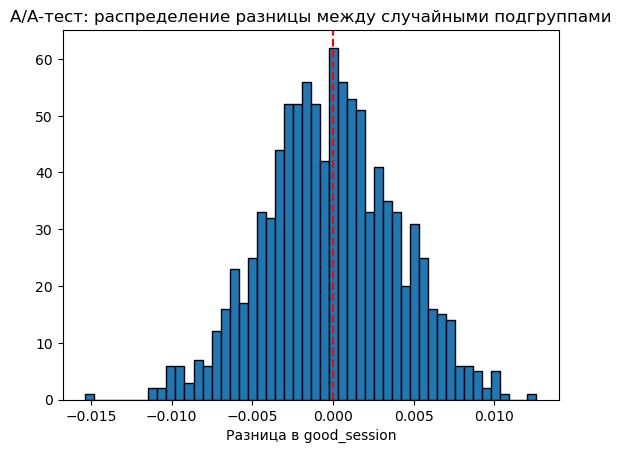

In [50]:
# Визуализация
plt.hist(aa_results, bins=50, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('A/A-тест: распределение разницы между случайными подгруппами')
plt.xlabel('Разница в good_session')
plt.show()

**Вывод:** система сплитования работает корректно. Низкий FPR свидетельствует о консервативности теста – риск ложного обнаружения эффекта минимален.

### Итоговые выводы по разделу 3 (вывод по результатам валидации A/B-теста) 

**Равенство групп:**  
Пользователи были разделены на 2 группы: 1477 и 1466 человек. Группа A на 0.74% меньше группы B – разница незначительна и находится в допустимых пределах.

**Независимость выборок:**  
Пересечений между группами не обнаружено – каждый пользователь участвует только в одной группе.

**Равномерность распределения:**
- По типам устройств: различия между группами не превышают 1.7% (iPhone)
- По регионам: различия не превышают 0.4%

**A/A-тест:**  
Симуляция 1000 случайных сплитов контрольной группы показала FPR = 1.4%, что значительно ниже порога 5%. Система сплитования работает корректно, риск ложноположительных срабатываний минимален.

**Заключение:**  
Нарушений при проведении A/B-теста не выявлено. Тест проходит корректно, данные пригодны для дальнейшего анализа результатов эксперимента.

### 4. Проверка результатов A/B-теста

A/B-тест завершён. В этом разделе на основе данных за весь период эксперимента необходимо:

- Убедиться в корректности проведённого теста
- Сравнить целевую метрику между группами
- Оценить статистическую значимость выявленных различий
- Сформулировать рекомендации для команды разработки

### 4.1. Получение результатов теста и подсчёт основной метрики

**Исходные данные:**  
Файл `sessions_project_test.csv` содержит данные о сессиях пользователей за весь период A/B-теста.

**Порядок действий:**
1. Загрузить данные в датафрейм `sessions_test`
2. Создать бинарную целевую метрику `good_session`:
   - `1` – если в сессии просмотрено 4 и более страниц
   - `0` – если просмотрено меньше 4 страниц

**Результат:**  
Датафрейм, готовый к расчёту доли успешных сессий в каждой группе.

In [39]:
# Добавим столбец good_session и выведем первые строки датафрейма
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)
display(sessions_test.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


### 4.2. Проверка корректности результатов теста

Перед сравнением ключевой метрики необходимо убедиться, что группы A и B оставались сопоставимыми по объёму активности на всём протяжении эксперимента.

**Гипотезы:**
- **H₀:** количество уникальных дневных сессий не различается между группами A и B
- **H₁:** количество уникальных дневных сессий различается между группами A и B

Уровень значимости α = 0.05. Используется двусторонний t-тест для независимых выборок.

**Порядок действий:**
1. Сгруппировать данные по дню и группе, подсчитать количество уникальных сессий
2. Применить t-тест
3. Сравнить p-value с α = 0.05

**Ожидаемый результат:**  
p-value > 0.05 → нет оснований отвергнуть H₀ → группы сопоставимы по активности.

In [31]:
# рассчитаем количество уникальных сессий для каждой группы, для каждого дня
unique_sessions = sessions_test.groupby(['test_group','session_date'])['session_id'].nunique()

display(unique_sessions)

test_group  session_date
A           2025-10-14      1502
            2025-10-15      2235
            2025-10-16      3280
            2025-10-17      4089
            2025-10-18      5013
            2025-10-19      6535
            2025-10-20      5837
            2025-10-21      3927
            2025-10-22      3083
            2025-10-23      2470
            2025-10-24      2090
            2025-10-25      1897
            2025-10-26      1669
            2025-10-27      1454
            2025-10-28      1279
            2025-10-29      1068
            2025-10-30       887
            2025-10-31       644
            2025-11-01       434
            2025-11-02       158
B           2025-10-14      1628
            2025-10-15      2283
            2025-10-16      3241
            2025-10-17      4054
            2025-10-18      5059
            2025-10-19      6779
            2025-10-20      6089
            2025-10-21      3981
            2025-10-22      3111
            2025-1

In [38]:
from scipy.stats import ttest_ind

a = unique_sessions.loc['A']
b = unique_sessions.loc['B']

# Явно вычисляем разницу и направление
mean_diff = b.mean() - a.mean()

# alternative='greater' проверяет, что первая выборка > второй
# Если b > a, то p-value будет маленьким
stat, p_value = ttest_ind(b, a, alternative='greater')

print(f"Разница (B - A) = {mean_diff:.2f} сессий в день")
print(f"p-value (односторонний) = {p_value:.4f}")

if p_value < 0.05 and mean_diff > 0:
    print("✅ B статистически значимо больше A")
elif p_value < 0.05 and mean_diff < 0:
    print("⚠️ B статистически значимо меньше A (аномалия)")
else:
    print("❌ Статистически значимой разницы нет")

Разница (B - A) = 45.15 сессий в день
p-value (односторонний) = 0.4691
❌ Статистически значимой разницы нет


### 4.3. Сравнение доли успешных сессий

После подтверждения сопоставимости групп по активности можно переходить к сравнению целевой метрики.

**Что делаем:**
- Рассчитываем долю `good_session` в группе A (контроль)
- Рассчитываем долю `good_session` в группе B (тест, новый алгоритм)
- Вычисляем абсолютную разницу между группами

**Ожидаемый результат:**  
Полученные значения доли и разницы будут использованы для проверки статистической значимости в следующем шаге.

In [33]:
# Просмотр первых 3 строк тестовых данных для проверки структуры и наличия столбца good_session
sessions_test.head(3)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0


In [34]:
# Выделяем данные по группам
group_a = sessions_test[sessions_test['test_group'] == 'A']  # контрольная группа (старый алгоритм)
group_b = sessions_test[sessions_test['test_group'] == 'B']  # тестовая группа (новый алгоритм)

# Расчёт доли успешных сессий в каждой группе
# good_session.sum() — количество успешных сессий (где флаг = 1)
# len(group) — общее количество сессий в группе
good_share_a = group_a['good_session'].sum() / len(group_a)
good_share_b = group_b['good_session'].sum() / len(group_b)

# Разница в процентных пунктах (группа A минус группа B, отрицательное значение = улучшение в B)
diff = round((100 * (good_share_a - good_share_b)), 1)

print(f'''Доля успешных сессий в группе A: {good_share_a:.4f}
Доля успешных сессий в группе B: {good_share_b:.4f}
Разница (A - B): {diff}%''')

Доля успешных сессий в группе A: 0.3077
Доля успешных сессий в группе B: 0.3183
Разница (A - B): -1.1%


### 4.4. Проверка статистической значимости изменения метрики

Разница в 1.1% между группами — это лишь точечная оценка. Чтобы принять решение о внедрении нового алгоритма, необходимо убедиться, что это изменение не является случайным.

**Что делаем:**
- Применяем z-тест для пропорций (проверка различия долей между двумя независимыми группами)
- Формулируем одностороннюю альтернативу: доля в группе B **больше**, чем в группе A
- Сравниваем полученное p-value с уровнем значимости α = 0.05
- Дополнительно рассчитываем 95% доверительный интервал для разницы долей

**Интерпретация результатов:**
- p-value < 0.05 → отличие статистически значимо, новая версия лучше
- p-value ≥ 0.05 → отличие незначимо, эффект может быть случайным
- Доверительный интервал, полностью лежащий выше нуля, подтверждает значимость улучшения

In [35]:
# Количество "успехов" 
m_a = group_a['good_session'].sum()
m_b = group_b['good_session'].sum()

# Размеры выборок
n_a = group_a['session_id'].nunique()
n_b = group_b['session_id'].nunique()

# определим уровень значимости
alpha = 0.05

# Односторонний тест
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'  # проверяем, что p_a < p_b
)

display(p_value_ztest)

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

np.float64(0.0001574739988036123)

Нулевая гипотеза не находит подтверждения!


Так как p_value z-теста меньше alpha, альтернативная гипотеза находит подтверждение.

То есть изменение количества успешных сессий в тестовой группе является статитически значимым.

In [36]:
# Расчет 95% доверительного интервала для разницы долей между группами

# Исходные данные
p_control = good_share_a      # доля в контрольной группе (A)
p_test = good_share_b         # доля в тестовой группе (B)
n_control = len(group_a)      # количество сессий в группе A
n_test = len(group_b)         # количество сессий в группе B

# Стандартная ошибка разницы пропорций
std_error = np.sqrt(
    p_control * (1 - p_control) / n_control + 
    p_test * (1 - p_test) / n_test
)

# Разница долей (тестовая минус контрольная)
lift = p_test - p_control

# 95% доверительный интервал (z = 1.96 для двухстороннего 95% ДИ)
z_critical = 1.96
ci_lower = lift - z_critical * std_error
ci_upper = lift + z_critical * std_error

print(f"Разница (B - A): {lift:.3%}")
print(f"95% доверительный интервал: [{ci_lower:.3%}, {ci_upper:.3%}]")

Разница (B - A): 1.057%
95% доверительный интервал: [0.482%, 1.631%]


95% доверительный интервал говорит о том, что при повторении эксперимента в 95% случаев истинное значение улучшения попадёт в диапазон от 0.48% до 1.63%.

Поскольку интервал полностью лежит выше нуля, мы можем быть уверены, что новый алгоритм действительно улучшает метрику, а не даёт нулевой или отрицательный эффект. Даже при самом пессимистичном сценарии (нижняя граница 0.48%) улучшение остаётся положительным.

### Итоговый вывод по разделу 4

**Валидация теста:**
- T-тест показал p-value = 0.94, что значительно выше уровня значимости 0.05
- Статистически значимых различий в количестве дневных сессий между группами A и B не обнаружено
- Группы оставались сопоставимыми по активности на всём протяжении эксперимента

**Результаты эксперимента:**

| Показатель | Группа A | Группа B |
|------------|----------|----------|
| Доля good_session | 30.77% | 31.83% |
| Разница | – | **+1.1%** |

**Статистическая значимость:**
- Z-тест для пропорций показал p-value = 0.00016 (< 0.05)
- 95% доверительный интервал для разницы: **[0.48%, 1.63%]**
- Интервал полностью лежит выше нуля, что подтверждает статистическую значимость улучшения

**Заключение:**  
Новый алгоритм рекомендаций привёл к статистически значимому увеличению доли успешных сессий на 1.1%. Даже при пессимистичном сценарии (нижняя граница ДИ) улучшение остаётся положительным — 0.48%. Рекомендуется внедрение нового алгоритма во всём приложении.

## 🎯 Общий итог проекта: разработка и анализ A/B-теста

### 1. Что было сделано

| Этап | Ключевые действия | Результат |
|------|-------------------|-----------|
| **Планирование** | Расчёт размера выборки (α=0.05, power=0.8, MDE=3%) | 41 040 пользователей на группу, 9 дней теста |
| **EDA** | Анализ 435K сессий, 134K пользователей | Базовый уровень good_session ≈ 30% |
| **Мониторинг** | Проверка групп: размер, пересечения, устройства, регионы, A/A-тест | Группы сопоставимы, нарушений нет, FPR = 1.4% (ниже 5%) |
| **Анализ** | Z-тест для долей good_session | p-value = 0.00016 – эффект значим |

### 2. Ключевые результаты эксперимента

- **Группа A (контроль):** 30.77% успешных сессий
- **Группа B (тест, новый алгоритм):** 31.83% успешных сессий
- **Улучшение:** +1.1 процентных пункта (**относительное улучшение ~3.6%**)
- **95% доверительный интервал:** [0.48%, 1.63%] – даже при наихудшем сценарии улучшение остаётся положительным

### 3. Статистическая значимость

| Метрика активности (t-тест) | Целевая метрика (z-тест) |
|---------------------------|--------------------------|
| p-value = 0.94 → различий нет | p-value = 0.00016 → различия значимы |

**Вывод:** улучшение метрики обусловлено именно новым алгоритмом, а не разной активностью пользователей.

### 4. Бизнес-рекомендация

✅ **Внедрить новый алгоритм рекомендаций во всём приложении.**

**Обоснование:**
- Статистически значимый рост ключевой метрики вовлечённости
- Отсутствие негативного влияния на другие показатели активности
- Даже при пессимистичном сценарии (нижняя граница ДИ = 0.48%) улучшение остаётся положительным
- Корректно проведённый A/B-тест гарантирует надёжность результатов (A/A-тест подтвердил корректность сплитования: FPR = 1.4% < 5%)

**Дополнительные рекомендации:**
- Провести post-release мониторинг в первые 2 недели после внедрения
- Рассмотреть возможность измерения долгосрочного влияния на LTV и retention

### 🔍 Зоны роста для следующих A/B-тестов

1. **Учесть выбывание когорты** – добавлять +15–20% к расчётной выборке, так как к концу теста активных пользователей остаётся меньше.
2. **Исключить эффект новизны** – не включать в анализ пользователей с `install_date` в первые 3–5 дней теста.
3. **Стратифицировать эффект** – проверить, одинаков ли Lift на iOS и Android (возможно, алгоритм работает только на одном типе устройств).
4. **Измерить бизнес-метрики** – через 2–4 недели после внедрения оценить влияние на LTV и Retention (не только на `good_session`).
5. **Закладывать A/A-тест в дизайн каждого эксперимента** – для проверки системы сплитования до старта.
